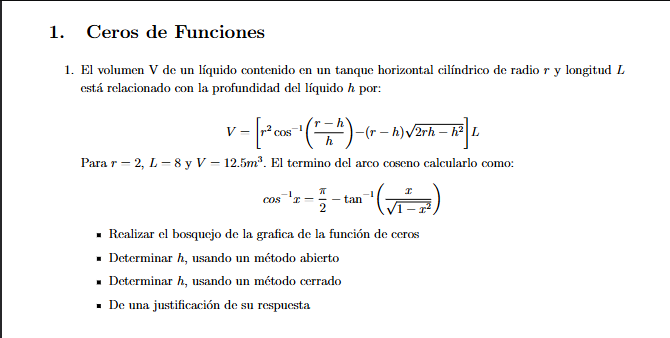

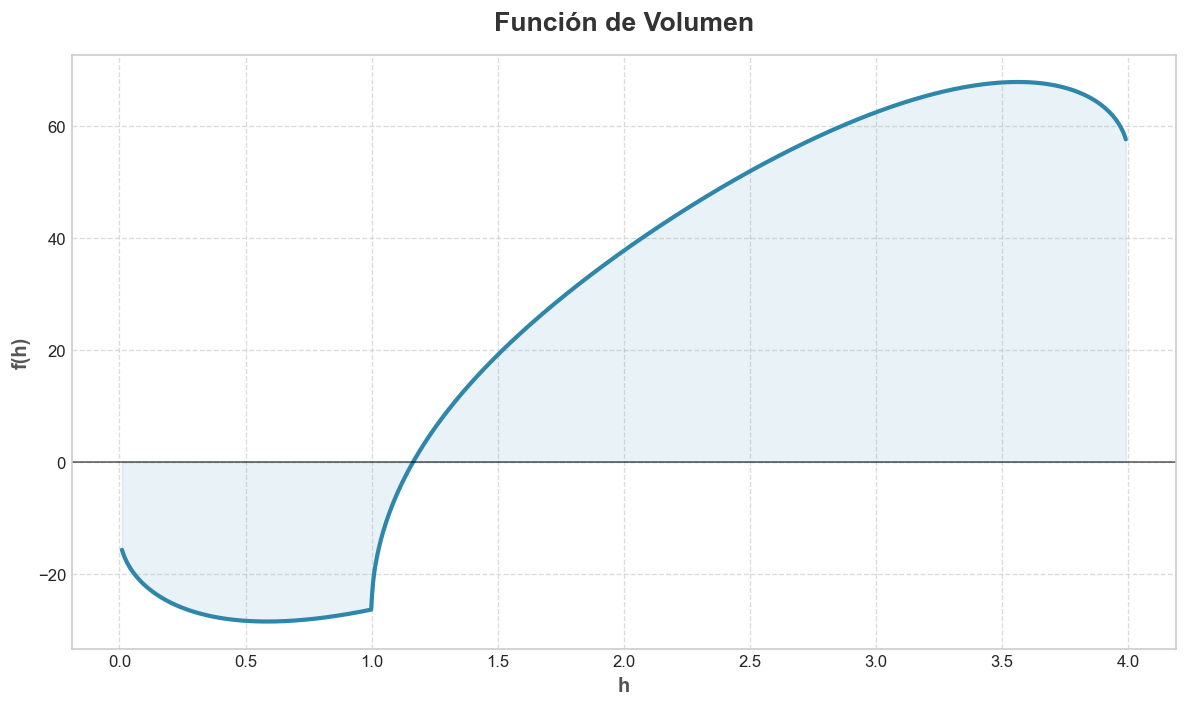

In [1]:
# Vamos a graficar la funcion con la idea de poner un intervalo [a,b] tal que exista la raíz.
# 
# Entonces, teniendo en cuenta que acos(x) = pi/2-atan(x/sqrt(1-x**2)) siendo x = (r - h) / r
# podemos graficarla sin problema

import numpy as np
import math
from graficador import graficar_funcion
from metodos_cerrados.biseccion.metodo_biseccion import biseccion
from metodos_cerrados.falsa_posicion.metodo_posicion_falsa import falsa_posicion
from metodos_abiertos.newton.metodo_newton import newton_rapshon
import sympy as sp

r = 2.0
L = 8.0
V_obj = 12.5

def mi_arccos(x):
    if abs(x) >= 1.0:
        if x >= 1.0: return 0.0
        if x <= -1.0: return math.pi
    return (math.pi / 2.0) - math.atan(x / math.sqrt(1.0 - x**2))

def funcion_problema_1(h):
    if h <= 0:
        return -V_obj
    if h >= 2*r:
        h = 2*r - 1e-9
    term_x = (r - h) / h
    volumen = (r**2 * mi_arccos(term_x) - (r - h) * math.sqrt(2*r*h - h**2)) * L
    return volumen - V_obj

f_tanque = funcion_problema_1



graficar_funcion(f_tanque, x_inicio=0.01, x_fin=3.99, titulo="Función de Volumen", xlabel="h", ylabel="f(h)")


In [3]:
#APROXIMAR h CON UN MÉTODO CERRADO: BISECCIÓN

#Podemos observar que nuestra raiz existe, y se encuentra en el intervalo [0.5,1], entonces aproximemos con el método de bisección
biseccion(f_tanque,0.5,1.5)


(1.1643190383911133, 20)

In [ ]:
# APROXIMAR h CON UN MÉTODO ABIERTO: NEWTON

# Para Newton-Raphson necesitamos una expresión simbólica, entonces hagamos la transición
h_sym = sp.symbols('h')
term_x_sym = (r - h_sym) / h_sym
f_sym = (r**2 * sp.acos(term_x_sym) - (r - h_sym) * sp.sqrt(2*r*h_sym - h_sym**2)) * L - V_obj
newton_rapshon(f_sym,0.5,1e-6,h_sym)


(3, 0.727904882907646)

## Justificación de la Respuesta

El Problema del Tanque Cilíndrico

El ejercicio del tanque cilíndrico horizontal no es solo un problema de geometría; es una excelente oportunidad para observar cómo el Análisis Numérico nos permite resolver problemas de ingeniería donde el álgebra tradicional queda corta.

1. Contextualización Matemática
En este ejercicio, buscábamos encontrar la altura $h$ (profundidad) del líquido necesaria para que un tanque cilíndrico de radio $r=2$ y longitud $L=8$ contenga un volumen $V = 12.5$.

La relación entre $h$ y $V$ se describe mediante una función trascendente: $$V = \left[ r^2 \cos^{-1}\left(\frac{r-h}{h}\right) - (r-h)\sqrt{2rh-h^2} \right] L$$

Debido a la combinación de funciones trigonométricas e irracionales, es imposible despejar $h$ analíticamente. Por tanto, planteamos el problema como una búsqueda de las raíces de la función: $$f(h) = V(h) - 12.5 = 0$$

2. Metodología y Justificación
Para llegar a la solución, aplicamos un flujo de trabajo típico de un analista numérico:

Análisis Gráfico (Exploración):

Graficar la función fue indispensable. Nos permitió confirmar visualmente que existe una raíz única dentro del rango físico del tanque ($0 < h < 4$).
Identificamos que en el intervalo $[1.0,1.5]$ la función cambia de signo, satisfaciendo las condiciones del Teorema de Bolzano.
Método de Bisección (Robustez):

Al ser un método cerrado, su convergencia está garantizada siempre que haya un cambio de signo en el intervalo.
Es ideal para una aproximación inicial segura, aunque requiere más iteraciones (19 en nuestro caso) para alcanzar una tolerancia de $10^{-6}$.
Método de Newton-Raphson (Eficiencia):

Como método abierto, destaca por su convergencia cuadrática (es muchísimo más rápido).
Aprovechamos la potencia de sympy para calcular la derivada exacta y aplicar el algoritmo.
Resultado: Newton halló la raíz en solo 3 iteraciones, demostrando ser la herramienta más eficiente una vez que tenemos una buena estimación inicial.